In [7]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import RemoveMessage

In [8]:
load_dotenv()

True

In [9]:
model=ChatOllama(model="llama3.2")

In [10]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [11]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [12]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [13]:
graph = builder.compile(checkpointer=InMemorySaver())

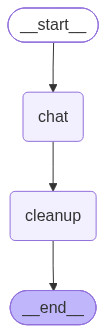

In [14]:
graph

In [15]:
config = {"configurable": {"thread_id": "t1"}}


In [16]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Pankaj Saini"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='bda5b3d5-0935-4464-ba04-5249fb83cbd7'),
  AIMessage(content='Langchain!\n\nLangchain is an open-source project that aims to make it easy to build and deploy large-scale language models and other NLP applications. Langchain is built on top of LangGraph, which provides a unified and efficient way to build and deploy machine learning models.\n\n**What is Langchain?**\n\nLangchain is a framework that provides a set of tools and libraries to build and deploy large-scale language models and other NLP applications. Langchain is designed to make it easy to work with language models, including:\n\n1. **Language model training**: Langchain provides a set of tools and libraries to train and fine-tune large-scale language models.\n2. **Language model deployment**: Langchain provides a set of tools and libraries to deploy and serve language models in production environments.\n3. **Language model 

In [17]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
